In [131]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from GB84_new import variables, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers, ambient_temp
from kalman_filter_2 import kalman_filter as kf
from sklearn.metrics import mean_squared_error

### Testing the model

In [132]:
measurements = xr.open_mfdataset(r'cesar_surface_meteo_lc1_t10_v1.0_202407.nc')

In [133]:
measurements

<xarray.Dataset> Size: 411kB
Dimensions:          (time: 4464, day_in_time_interval: 31, nv: 2)
Coordinates:
  * time             (time) datetime64[ns] 36kB 2024-07-01 ... 2024-07-31T23:...
Dimensions without coordinates: day_in_time_interval, nv
Data variables: (12/22)
    iso_dataset      |S1 1B ...
    product          |S1 1B ...
    station_details  |S1 1B ...
    date             (time) int32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    valid_dates      (day_in_time_interval) int8 31B dask.array<chunksize=(31,), meta=np.ndarray>
    time_bnds        (time, nv) datetime64[ns] 71kB dask.array<chunksize=(4464, 2), meta=np.ndarray>
    ...               ...
    F010             (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    IF010            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    D010             (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    ID010            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    TD002            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    RH002            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
Attributes:
    institution:              Royal Netherlands Meteorological Institute (KNMI)
    comment:                  none
    Conventions:              CF-1.4
    location:                 CESAR observatory, the Netherlands
    file_creation_date_time:  20240826 10:49:12 (UTC)
    references:               cesar_surface_meteo_lc1_t10_v1.0.pdf @ http://w...
    history:                  Continuous observations are performed, gap fill...

In [134]:
slice_str = "2024-07-05 00:00:00, 2024-07-07 23:59:00"
slice_tuple = tuple(slice_str.split(", "))

#### Radiometer LWC 

In [135]:
cabaw = xr.open_mfdataset(r'data\Cabaw_radiometer\*.nc')
reference_date = np.datetime64("2024-07-01")

# Convert minutes into datetime
#datetime_values = reference_date + measurements.time.astype("timedelta64[m]")
#measurements['time'] = datetime_values

july = cabaw.sel(time=slice(*slice_tuple))

In [136]:
#var = ['temperature','pressure','humidity','rain_rate']
var = ['TA002','P0','TD002','RH002']
measurements = measurements[var]
measurements = measurements.dropna(dim='time',how='any')
measurements_used = measurements.sel(time=slice(*slice_tuple))

In [137]:
measurements

<xarray.Dataset> Size: 107kB
Dimensions:  (time: 4464)
Coordinates:
  * time     (time) datetime64[ns] 36kB 2024-07-01 ... 2024-07-31T23:49:59.92...
Data variables:
    TA002    (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    P0       (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    TD002    (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    RH002    (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
Attributes:
    institution:              Royal Netherlands Meteorological Institute (KNMI)
    comment:                  none
    Conventions:              CF-1.4
    location:                 CESAR observatory, the Netherlands
    file_creation_date_time:  20240826 10:49:12 (UTC)
    references:               cesar_surface_meteo_lc1_t10_v1.0.pdf @ http://w...
    history:                  Continuous observations are performed, gap fill...

#Kalman filter measurements

kf_measurements = measurements['rain_rate'].values[7000:10000:30]

In [138]:
parsivel_1 = xr.open_dataset(r'data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values

In [139]:
rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=measurements.time,method='nearest')

In [140]:
#kf_measurements = rain_rate.isel(time=slice(None, None, 6))
kf_measurements_used = rain_rate.sel(time=slice(*slice_tuple))

In [141]:
kf_measurements_used

<xarray.DataArray 'rainfall_rate_32bit' (time: 432)> Size: 2kB
[432 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[s] 3kB 2024-07-05 ... 2024-07-07T23:50:00
Attributes:
    long_name:  average rainfall rate over the last minute
    units:      mm/h
    comment:    Field 01 in technical documentation

#inputs

#temperature on the ground
T_surf_C = measurements_used['temperature'].values #[C]
T_surf = T_surf_C + 273.15    # [K]

#pressure
p_surf = measurements_used['pressure'].values*100  #[Pa]

#dew point temperature
RH = measurements_used['humidity'].values
alpha_T = 17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH/100) #from http://dx.doi.org/10.31648/ts.5425
T_d_arr = 237.7*alpha_T/(17.27 - alpha_T) + 273.15      #[K]

#state
X = np.zeros(len(T_surf))
X[0] = july.lwp[0]   #initial state in kg/m2
Sigma = np.zeros(len(T_surf))
Sigma[0] = 5 #initial state covariance in kg/m2

#timestep
dt= 600      #timestep in s

In [142]:
#inputs

#temperature on the ground
T_surf = measurements_used['TA002'].values #[K]


#pressure
p_surf = measurements_used['P0'].values*100  #[Pa]

#dew point temperature
T_d_arr = measurements_used['TD002'].values     #[K]

#state
X = np.zeros(len(T_surf))
X[0] = july.lwp[0]   #initial state in kg/m2
#X = july.lwp.sel(time=measurements_used.time,method='nearest').values
Sigma = np.zeros(len(T_surf))
Sigma[0] = 1 #initial state covariance in kg/m2

#timestep
dt= 600      #timestep in s

In [143]:
RH = measurements_used['RH002'].values
T_surf_C =T_surf - 273.15
alpha_T = 17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH/100) #from http://dx.doi.org/10.31648/ts.5425
T_d_arr_2 = 237.7*alpha_T/(17.27 - alpha_T) + 273.15      #[K]

In [144]:
july.lwp.sel(time=measurements_used.time,method='nearest').values.min()

nan

In [145]:
#loop for finding the precipitation given the T_0 and p
P = np.zeros(len(T_surf))
P_0 = np.zeros(len(T_surf))
t_lower =0
f_arr = np.zeros(len(T_surf))
h_arr = np.zeros(len(T_surf))
j = 0
Q = 0.32
for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = variables(T_0, T_d, p_0, obs=False).run()
    T_l_up = ambient_temp(T_0,p_0,p_s,T_s)
    T_t_up = ambient_temp(T_0,p_0,p_t,T_t)
    #print(T_l_up,T_s)
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr_l = v(T_s,T_l_up)
    
    #print(v_updr_t)
    v_updr_t = v(T_t,T_t_up)
    v_updr = v(T_m,T_s_up)*10
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,v_updr_l,v_updr_t,Z_c,2).run()   #outflows and sources of water
    

    f_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr_l)
        
    h_arr[i] = h_out(v_updr,v_updr_l,v_updr_t,Z_c,2).run()[2]
    #precipitation in kg/m2/s
    #P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr_l,v_updr_t,2).calculate_phi()*3
    #P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr_l).calculate_phi()*X[i] #*X[i] if we are using the updated state
    #print(phi(T_0, p_0, T_d, Z_b, Z_c,v_updr_l).calculate_phi()*3600)
    #state without Kalman filter
    
    #print(T_s_up,T_m)
    #state with Kalman filter   
    if i>=0:
        if (i>0):
            #X[i] = max(0,X[i] + (np.trapz([f_arr[j:i+1]], dx=dt)) - np.trapz([h_arr[j:i+1]*X[j:i+1]], dx=dt))
            #Sigma[i] = Sigma[i] + 2*np.trapz([h_arr[j:i+1]*Sigma[j:i+1]], dx=dt) + Q*dt*(i - j)

            P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr,v_updr_l,v_updr_t,2).calculate_phi()*3
            P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr,v_updr_l,v_updr_t,2).calculate_phi()*X[i]
        if (((i%12)==0)&(i>0)):
            # we assume that we receive a precipitation update every 60mins
            j = i
            print(j)
            
            phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr,v_updr_l,v_updr_t,2).calculate_phi()
            h_kf = h_out(v_updr,v_updr_l,v_updr_t,Z_c,2).run()[2]
            f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr_l)
            
            kalman_f = kf(X[i], Sigma[i], dt,h_kf,phi_kf,f_kf,kf_measurements_used[j].values) 
            X[i],Sigma[i],X_apr = kalman_f.update()
            #print(X[i],X_apr)
        
        #print(h_arr[i])

        
        if i<(len(T_surf)-1):
            print(np.trapz([f_arr[j:i+1] - h_arr[j:i+1]*X[j:i+1]], dx=dt))
            X[i+1] = max(0,X[i] + (np.trapz([f_arr[j:i+1]], dx=dt)) - np.trapz([h_arr[j:i+1]*X[j:i+1]], dx=dt))
            Sigma[i+1] = Sigma[i] + 2*np.trapz([h_arr[j:i+1]*Sigma[j:i+1]], dx=dt) + Q*dt*(i - j)


[0.]
[0.00825073]
[0.01479722]
[0.01676642]
[0.01267534]
[0.0029603]
[-0.00972391]
[-0.02123758]
[-0.02718048]
[-0.02428013]
[-0.01330149]
[0.00089149]
12
[0.]
[0.01402941]
[0.02534599]
[0.02937377]
[0.02324154]
[0.00732507]
[-0.01411144]
[-0.03420578]
[-0.04544274]
[-0.0420672]
[-0.02935081]
[-0.01560559]
24
[0.]
[0.01356675]
[0.02450461]
[0.02851703]
[0.0229818]
[0.00832592]
[-0.01190141]
[-0.03136108]
[-0.04276478]
[-0.04074625]
[-0.02898375]
[-0.01501119]
36
[0.]
[0.01440244]
[0.02651139]
[0.03135055]
[0.02535907]
[0.00876018]
[-0.01399803]
[-0.03562557]
[-0.04816493]
[-0.04562304]
[-0.03326865]
[-0.01977992]
48
[0.]
[0.01483983]
[0.02758101]
[0.03264343]
[0.02614305]
[0.0079881]
[-0.01659769]
[-0.0387086]
[-0.05079171]
[-0.04863256]
[-0.03772841]
[-0.0252661]
60
[0.]
[-0.5604482]
[-1.01739737]
[-1.18747353]
[-1.17212487]
[-1.15620403]
[-1.14022552]
[-1.12413966]
[-1.10815981]
[-1.09235745]
[-1.07657807]
[-1.06113111]
72
[0.]
[-0.63965687]
[-1.16179748]
[-1.35718452]
[-1.34175817]


In [146]:
import numpy as np
a = np.array([1,2,3])
j = sum(a[0:2])
print(j)

3


In [147]:
X[-1]

0.0

### Plots and results

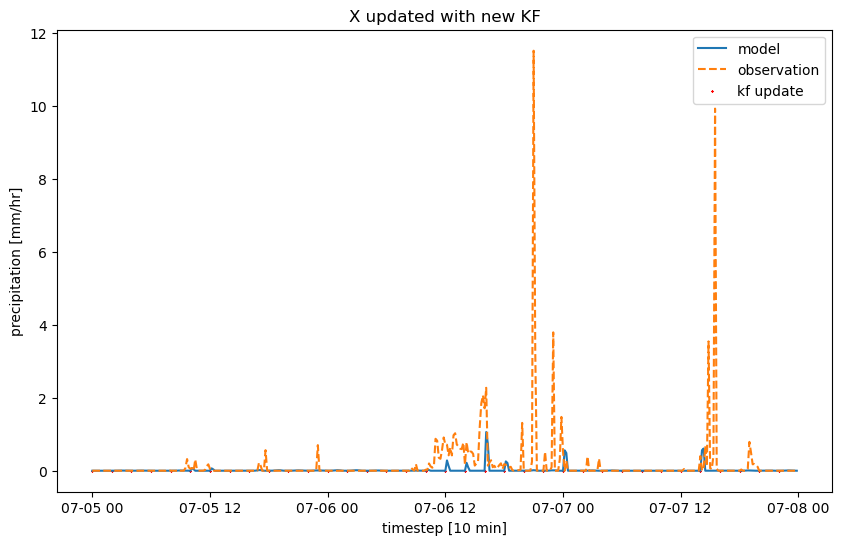

In [148]:
plt.figure(figsize=(10,6))
t_step = np.linspace(0,len(P),len(P))

plt.plot(measurements_used.time,P*3600,label='model')   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
#plt.plot(t_step,P_0*3600,label='model (steady state)')
plt.plot(measurements_used.time,rain_rate.sel(time=slice(*slice_tuple)),label='observation',linestyle='dashed')
plt.scatter(measurements_used.time[0::12],np.zeros((len(kf_measurements_used[0::12]))),label='kf update',marker='x',s=0.6,color='red')

plt.xlabel('timestep [10 min]')
plt.title('X updated with new KF')
plt.ylabel('precipitation [mm/hr]')
plt.legend()
plt.show()


In [149]:
rmse = mean_squared_error(rain_rate.sel(time=slice(*slice_tuple)),P*3600)
print(rmse)

0.6983128207584733


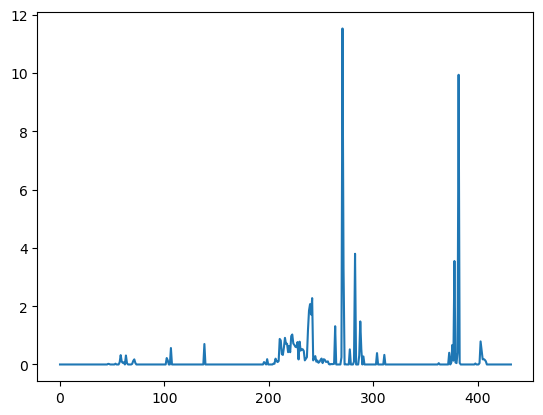

In [150]:
plt.plot(t_step,rain_rate.sel(time=slice(*slice_tuple)),label='observation')

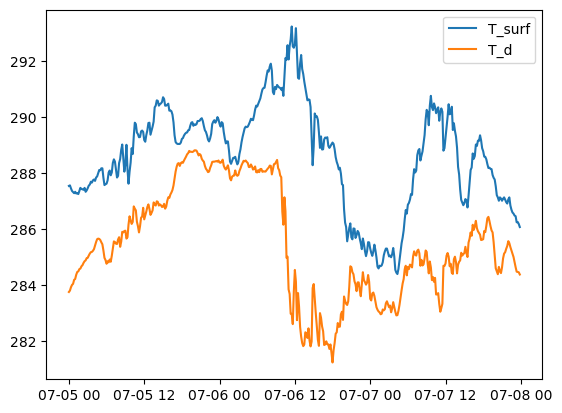

In [151]:
plt.plot(measurements_used.time,T_surf,label='T_surf')
plt.plot(measurements_used.time,T_d_arr,label='T_d')
plt.legend()

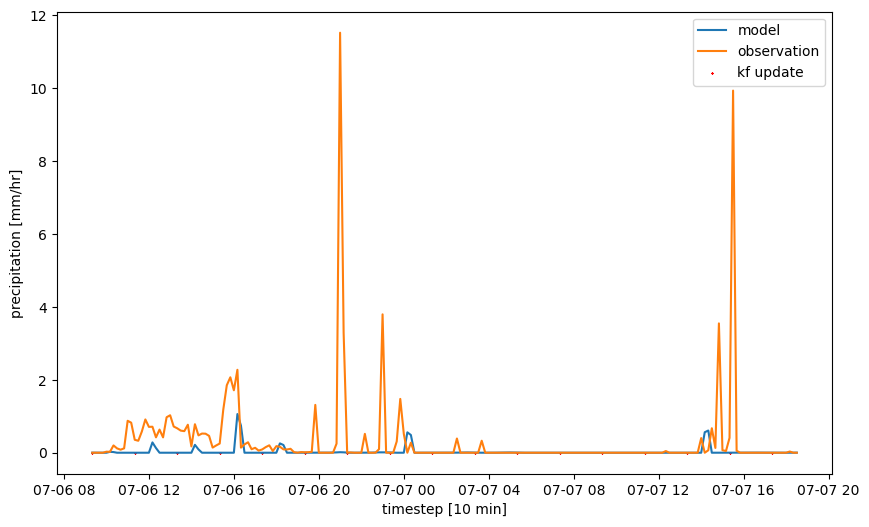

In [152]:
#zooming when no rain is observed
plt.figure(figsize=(10,6))
t_step = np.linspace(0,len(P),len(P))
plt.plot(measurements_used.time[200:400],P[200:400]*3600,label='model')
plt.plot(measurements_used.time[200:400],rain_rate.sel(time=slice(*slice_tuple))[200:400],label='observation')
plt.scatter(measurements_used.time[200:400:12],np.zeros((len(kf_measurements_used[200:400:12]))),label='kf update',marker='x',s=0.6,color='red')
plt.legend()
plt.xlabel('timestep [10 min]')
plt.ylabel('precipitation [mm/hr]')
plt.show()


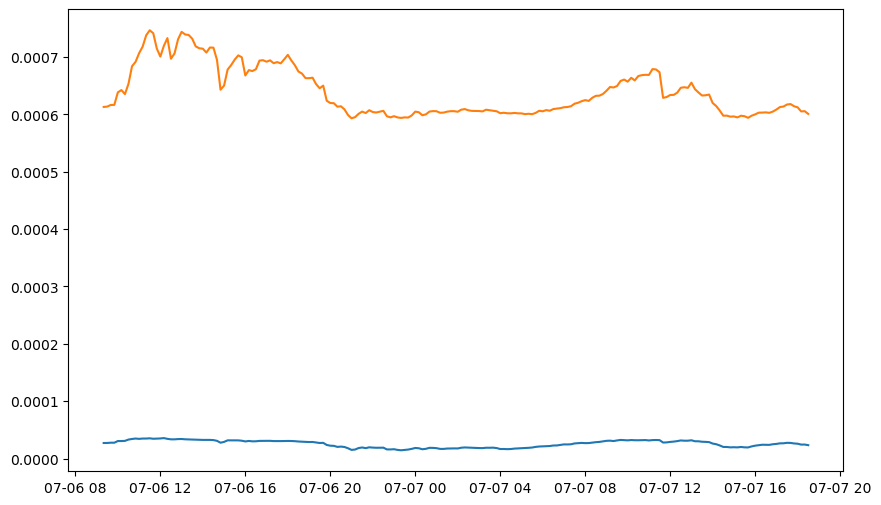

In [153]:
plt.figure(figsize=(10,6))
plt.plot(measurements_used.time[200:400],f_arr[200:400],label='model')
plt.plot(measurements_used.time[200:400],h_arr[200:400],label='model')
#plt.plot(measurements_used.time[200:400],rain_rate.sel(time=slice(*slice_tuple))[200:400],label='observation')

Text(0, 0.5, 'liquid water [kg/m^2]')

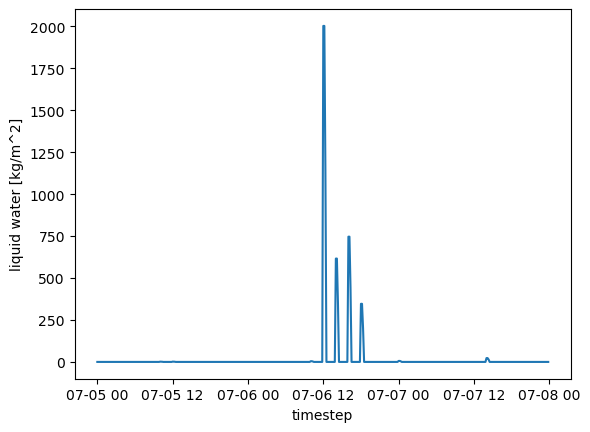

In [154]:
#state evolution

plt.plot(measurements_used.time,X)
#plt.plot(july.time,july.lwp)
plt.xlabel('timestep')
#plt.ylim(0,100)
plt.ylabel('liquid water [kg/m^2]')

Text(0, 0.5, 'average hourly precipitation (mm/hr)')

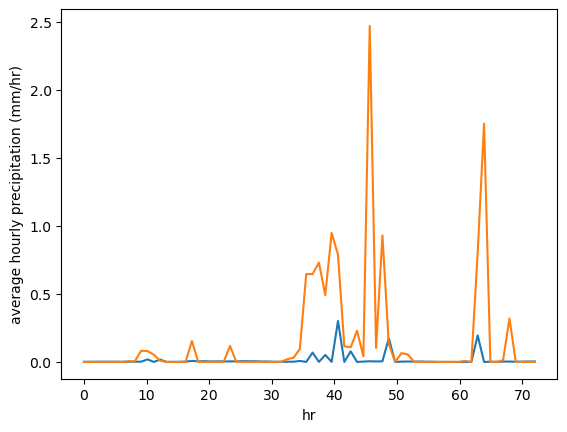

In [155]:
Pmeas = rain_rate.sel(time=slice(*slice_tuple))
averages_P = [np.mean(P[i:i+6]) for i in range(0, len(P), 6)]
averages_Pmeas=[np.mean(Pmeas[i:i+6]) for i in range(0, len(P), 6)]
t_hr = np.linspace(0,len(averages_P),len(averages_P))

plt.plot(t_hr,np.array(averages_P)*3600,label='model (Kf)')   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(t_hr,averages_Pmeas,label='observation')
plt.xlabel('hr')
plt.ylabel('average hourly precipitation (mm/hr)')

In [156]:
v_arr = np.zeros(len(T_surf))
O_b_arr = np.zeros(len(T_surf))
O_h_arr = np.zeros(len(T_surf))
I_arr = np.zeros(len(T_surf))

for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = variables(T_0, T_d, p_0, obs=False).run()
    T_l_up = ambient_temp(T_0,p_0,p_s,T_s)
    T_t_up = ambient_temp(T_0,p_0,p_t,T_t)
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr_l = v(T_s,T_l_up)
    
    v_updr_t = v(T_t,T_t_up)
    v_updr = v_updr_t*10
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,v_updr_l,v_updr_t,Z_c,2).run()
    v_arr[i] = v_updr
    print(non_dim_numbers(v_updr)[1])
    O_b_arr[i] = O_b*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    O_h_arr[i] = O_t*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    I_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
     


[5.43953869]
[5.44584002]
[5.46363271]
[5.47578588]
[5.48176909]
[5.50101918]
[5.50407708]
[5.52492193]
[5.53799389]
[5.54117255]
[5.54978247]
[5.55045933]
[5.56172738]
[5.56717363]
[5.57806474]
[5.58471636]
[5.59135588]
[5.60094205]
[5.60074916]
[5.60954163]
[5.61802808]
[5.62264465]
[5.62454212]
[5.6282146]
[5.63548516]
[5.65350308]
[5.66681071]
[5.6790808]
[5.6792424]
[5.67566435]
[5.67071179]
[5.65881261]
[5.6496718]
[5.62774414]
[5.59872652]
[5.58765185]
[5.5701977]
[5.57970093]
[5.56895508]
[5.58064569]
[5.57349078]
[5.59906931]
[5.6260666]
[5.65585784]
[5.65495774]
[5.65292901]
[5.65752336]
[5.67723823]
[5.67812139]
[5.63082583]
[5.6470677]
[5.68827165]
[5.6967175]
[5.71321322]
[5.70904119]
[5.65726587]
[5.68251183]
[5.75192103]
[5.78092743]
[5.75454524]
[5.7274429]
[5.74123306]
[5.79791865]
[5.7757146]
[5.76918223]
[5.72481002]
[5.70554796]
[5.67968181]
[5.70796651]
[5.74199919]
[5.74640691]
[5.78755628]
[5.7414638]
[5.76104562]
[5.77350296]
[5.78999652]
[5.79520138]
[5.7743771

Text(0, 0.5, 'updraft velocity [m/s]')

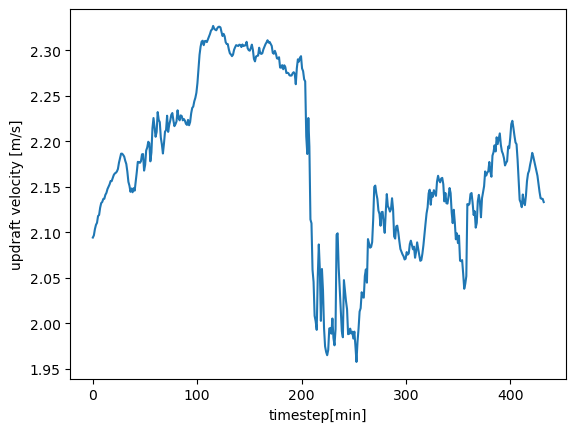

In [157]:
plt.plot(t_step,v_arr)
plt.xlabel('timestep[min]')
plt.ylabel('updraft velocity [m/s]')

Text(0.5, 1.0, 'Cloud Fluxes')

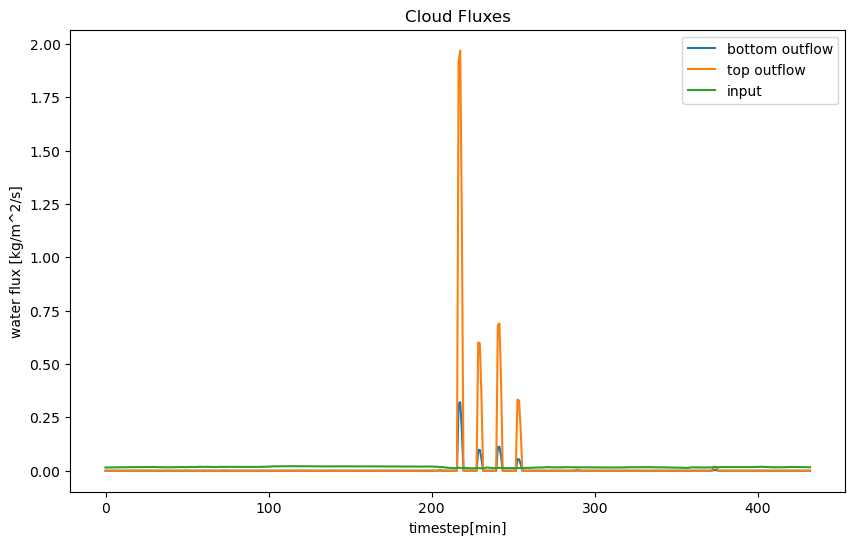

In [158]:
A = np.zeros(30000)
#for i in range(0,3000):
    #if measurements['rain_rate'].values[7000+i]>0:
        #A[i] = t_step[i]
    #else:
        #A[i] = 0
    

plt.figure(figsize=(10,6))
plt.plot(t_step,O_b_arr,label='bottom outflow')
plt.plot(t_step,O_h_arr,label='top outflow')
plt.plot(t_step,I_arr,label='input')
plt.xlabel('timestep[min]')
plt.ylabel('water flux [kg/m^2/s]')
#plt.vlines(A,0,0.005,alpha=0.1,color='red')
plt.legend()
plt.title('Cloud Fluxes')

In [159]:
O_b

0.9984256273268926

In [160]:
X[i]*non_dim_numbers(v_updr)[0]/Z_c

array([0.])

In [161]:
T_t

array([246.24067734])